# Actual First Training Code


In [ ]:
!pip install transformers datasets torch scikit-learn pandas

In [ ]:
# Cell 1 — Imports
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [ ]:
df = pd.read_csv('my_dataset.csv')
df = df[['complaint_text', 'priority']].dropna()
# Encode labels: High=0, Medium=1, Low=2 (or whatever your labels are)
le = LabelEncoder()
df['label'] = le.fit_transform(df['priority'])

In [ ]:
# Cell 3 — Create a PyTorch Dataset class
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ComplaintDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Cell 4 — Split data and create DataLoaders
X_train, X_val, y_train, y_val = train_test_split(
    df['complaint_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

train_dataset = ComplaintDataset(X_train, y_train)
val_dataset   = ComplaintDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Training samples: 1600, Validation samples: 400


In [ ]:
# Cell 5 — Load DistilBERT model
num_labels = len(le.classes_)  # e.g. 3 for High/Medium/Low

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Training on: {device}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training on: cuda


In [ ]:
# Cell 6 — Training loop
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total * 100
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Accuracy: {accuracy:.2f}%")

Epoch 1/3 | Loss: 0.5900 | Val Accuracy: 94.25%
Epoch 2/3 | Loss: 0.0770 | Val Accuracy: 99.75%
Epoch 3/3 | Loss: 0.0201 | Val Accuracy: 100.00%


In [ ]:
# Cell 7 — Save the model (IMPORTANT!)
model.save_pretrained('./complaintNLP_model')
tokenizer.save_pretrained('./complaintNLP_model')

# Also save your label mapping
import json
label_map = dict(zip(le.transform(le.classes_).tolist(), le.classes_.tolist()))
with open('./complaintNLP_model/label_map.json', 'w') as f:
    json.dump(label_map, f)

print("Model saved! Now download the 'complaint_model' folder.")

In [ ]:
!zip -r complaintNLP_model.zip complaintNLP_model

In [ ]:
# Cell 8 — Quick prediction test
model.eval()  # Make sure model is in eval mode

def test_prediction(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=128,
        padding='max_length'
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}  # move to GPU if available

    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()

    priority   = le.inverse_transform([pred_id])[0]  # converts number back to label
    confidence = probs[0][pred_id].item() * 100

    print(f"Text      : {text}")
    print(f"Prediction: {priority}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"All scores: { {le.inverse_transform([i])[0]: f'{probs[0][i].item()*100:.1f}%' for i in range(len(le.classes_))} }")
    print("-" * 60)

# Test with your own complaint sentences
test_prediction("My internet has been down for 3 days and I work from home")
test_prediction("I want to update my billing address")
test_prediction("The service is okay but I have a small question about my plan")
test_prediction("There is the gas leakage in block A ")
test_prediction("Can I get a copy of last month's invoice please")

Text      : My internet has been down for 3 days and I work from home
Prediction: Medium
Confidence: 96.98%
All scores: {'High': '2.8%', 'Low': '0.2%', 'Medium': '97.0%'}
------------------------------------------------------------
Text      : I want to update my billing address
Prediction: Low
Confidence: 99.34%
All scores: {'High': '0.2%', 'Low': '99.3%', 'Medium': '0.4%'}
------------------------------------------------------------
Text      : The service is okay but I have a small question about my plan
Prediction: Medium
Confidence: 99.31%
All scores: {'High': '0.3%', 'Low': '0.4%', 'Medium': '99.3%'}
------------------------------------------------------------
Text      : There is the gas leakage in block A 
Prediction: Low
Confidence: 89.24%
All scores: {'High': '1.3%', 'Low': '89.2%', 'Medium': '9.5%'}
------------------------------------------------------------
Text      : Can I get a copy of last month's invoice please
Prediction: Medium
Confidence: 93.48%
All scores: {'High'

fixing the dataset issue

In [ ]:
print("Label distribution in your dataset:")
print(df['priority'].value_counts())
print("\nAs percentages:")
print(df['priority'].value_counts(normalize=True) * 100)

Label distribution in your dataset:
priority
High      668
Medium    666
Low       666
Name: count, dtype: int64

As percentages:
priority
High      33.4
Medium    33.3
Low       33.3
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('my_dataset.csv')
df = df[['complaint_text', 'priority']].dropna()

# Verify balance BEFORE doing anything else
print("Label distribution:")
print(df['priority'].value_counts())
print("\nAs percentages:")
print(df['priority'].value_counts(normalize=True) * 100)

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['priority'])

print("\nLabel mapping (number → word):")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\nTotal samples: {len(df)}")

Label distribution:
priority
High      668
Medium    666
Low       666
Name: count, dtype: int64

As percentages:
priority
High      33.4
Medium    33.3
Low       33.3
Name: proportion, dtype: float64

Label mapping (number → word):
  0 → High
  1 → Low
  2 → Medium

Total samples: 2000


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ComplaintDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.texts   = texts
        self.labels  = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
#stratify=df['label'] is new. Without it, random splitting could accidentally put most "High" samples in training and very few in validation, making your accuracy report misleading
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df['complaint_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']   # ← NEW: ensures each split has equal class ratio
)

train_dataset = ComplaintDataset(X_train, y_train)
val_dataset   = ComplaintDataset(X_val,   y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Verify split is also balanced
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining label distribution:")
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

Training samples:   1600
Validation samples: 400

Training label distribution:
  High: 534
  Low: 533
  Medium: 533


In [ ]:
import torch.nn as nn
from transformers import DistilBertForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight

# Load model
num_labels = len(le.classes_)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
print(f"Training on: {device}")

# Compute class weights ← NEW
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"\nClass weights:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {class_weights[i]:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training on: cuda

Class weights:
  High: 0.9988
  Low: 1.0006
  Medium: 1.0006


In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
EPOCHS    = 5  # increased from 3 to 5

best_accuracy = 0.0

for epoch in range(EPOCHS):
    # ── Training phase ───────────────────────────────────────
    model.train()
    total_loss   = 0
    train_correct = 0
    train_total   = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # ← NEW: use weighted loss instead of outputs.loss
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track training accuracy too
        preds = torch.argmax(outputs.logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    avg_loss       = total_loss / len(train_loader)
    train_accuracy = train_correct / train_total * 100

    # ── Validation phase ─────────────────────────────────────
    model.eval()
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_accuracy = val_correct / val_total * 100

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")

    # Save the best model automatically ← NEW
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        model.save_pretrained('./complaintDesk_model')
        tokenizer.save_pretrained('./complaintDesk_model')
        print(f"  ↑ Best model saved! ({val_accuracy:.2f}%)")

print(f"\nTraining complete. Best validation accuracy: {best_accuracy:.2f}%")

Epoch 1/5 | Loss: 0.6429 | Train Acc: 75.56% | Val Acc: 95.75%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↑ Best model saved! (95.75%)
Epoch 2/5 | Loss: 0.0723 | Train Acc: 98.62% | Val Acc: 100.00%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↑ Best model saved! (100.00%)
Epoch 3/5 | Loss: 0.0163 | Train Acc: 99.75% | Val Acc: 100.00%
Epoch 4/5 | Loss: 0.0056 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch 5/5 | Loss: 0.0222 | Train Acc: 99.19% | Val Acc: 99.50%

Training complete. Best validation accuracy: 100.00%


In [ ]:
import json

# Save the label map with the best model
label_map = {str(i): cls for i, cls in enumerate(le.classes_)}

with open('./complaintDesk_model/label_map.json', 'w') as f:
    json.dump(label_map, f)

print("Label map saved:", label_map)
print("\nFiles in complaintDesk_model folder:")
import os
for f in os.listdir('./complaintDesk_model'):
    size = os.path.getsize(f'./complaintDesk_model/{f}')
    print(f"  {f:40s} {size/1024/1024:.1f} MB" if size > 1024 else f"  {f}")

Label map saved: {'0': 'High', '1': 'Low', '2': 'Medium'}

Files in complaintDesk_model folder:
  config.json
  tokenizer.json                           0.7 MB
  model.safetensors                        255.4 MB
  tokenizer_config.json
  label_map.json


In [ ]:
#extras 1
import pandas as pd

df = pd.read_csv('my_dataset.csv')  # ← change to your filename
print(df.columns.tolist())            # show column names
print(df.head(3))                     # show first 3 rows

['complaint_text', 'category', 'priority']
                                      complaint_text    category priority
0  the printer in the library has been broken for...     Library   Medium
1  a classmate records me during lectures without...  Harassment   Medium
2  the hostel common room has no working fans dur...      Hostel   Medium


In [ ]:
#extras 2
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Load dataset
df = pd.read_csv('my_dataset.csv')  # ← change to your filename

print(f"Total complaints: {len(df)}")
print("\nPriority Distribution:")
print(df['priority'].value_counts())

Total complaints: 2000

Priority Distribution:
priority
High      668
Medium    666
Low       666
Name: count, dtype: int64


In [ ]:
#extras 3
import torch

# Detect which device is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to the right device
model = model.to(device)

def predict_priority(complaint_text):
    """Takes a complaint and returns predicted priority label."""

    inputs = tokenizer(
        complaint_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    # Move inputs to same device as model ← THIS IS THE FIX
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_index = str(torch.argmax(outputs.logits).item())
    priority = label_map[predicted_index]

    probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)
    confidence = round(torch.max(probabilities).item() * 100, 2)

    return priority, confidence

print("✅ predict_priority function is ready!")



Using device: cuda
✅ predict_priority function is ready!


In [ ]:
#extras 5
true_labels = []
predicted_labels = []

print("Running model on entire dataset... please wait ⏳")

for i, row in tqdm(df.iterrows(), total=len(df)):
    complaint = row['complaint_text']
    actual = row['priority']

    predicted, confidence = predict_priority(complaint)

    true_labels.append(actual)
    predicted_labels.append(predicted)

print("✅ Done!")

Running model on entire dataset... please wait ⏳


100%|██████████| 2000/2000 [00:10<00:00, 192.37it/s]

✅ Done!


In [ ]:
#Extras 6
print("=" * 55)
print("        COMPLETE MODEL EVALUATION REPORT")
print("=" * 55)

# Overall Accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"\n✅ Accuracy  : {round(accuracy * 100, 2)}%")

# Full Report
print("\n📊 Detailed Classification Report:")
print("-" * 55)
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=["High", "Medium", "Low"]
)
print(report)

        COMPLETE MODEL EVALUATION REPORT

✅ Accuracy  : 99.65%

📊 Detailed Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

        High       1.00      0.99      0.99       668
      Medium       1.00      1.00      1.00       666
         Low       0.99      1.00      0.99       666

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



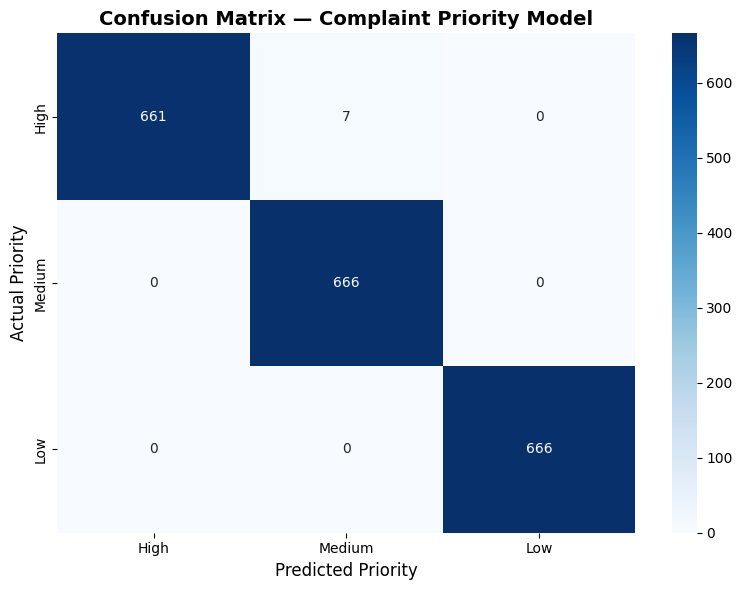

✅ Confusion matrix saved!


In [ ]:
#extras 6
#confusion matrix
label_names = ["High", "Medium", "Low"]
cm = confusion_matrix(true_labels, predicted_labels, labels=label_names)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix — Complaint Priority Model", fontsize=14, fontweight='bold')
plt.ylabel("Actual Priority", fontsize=12)
plt.xlabel("Predicted Priority", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [ ]:
#extras 7
print(model.config)

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.12.0",
  "vocab_size": 30522
}



Test Prediction

In [ ]:
model.eval()

def test_prediction(text, expected=None):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=128,
        padding='max_length'
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()

    priority   = le.inverse_transform([pred_id])[0]
    confidence = probs[0][pred_id].item() * 100
    all_scores = {le.inverse_transform([i])[0]: f'{probs[0][i].item()*100:.1f}%'
                  for i in range(len(le.classes_))}

    status = ""
    if expected:
        status = "✓" if priority == expected else f"✗ (expected {expected})"

    print(f"Text      : {text}")
    print(f"Prediction: {priority} {status}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"All scores: {all_scores}")
    print("-" * 60)

test_prediction("My internet has been down for 3 days, I work from home",      expected="High")
test_prediction("There is a gas leak in my building, this is an emergency",    expected="High")
test_prediction("I have been waiting for a refund for 2 weeks",                expected="Medium")
test_prediction("The app crashes sometimes when I open it",                    expected="Medium")
test_prediction("I want to update my billing address",                         expected="Low")
test_prediction("Can I get a copy of last month's invoice please",             expected="Low")

# These match your actual training domain
test_prediction("the portal is down and i cant submit my assignment deadline is today",     expected="High")
test_prediction("a student was attacked in the hostel and security did nothing",            expected="High")
test_prediction("teacher hasnt returned our assignments for over a week",                   expected="Medium")
test_prediction("the library has been closed for 4 days without any notice",               expected="Medium")
test_prediction("the cafeteria menu should have more variety",                              expected="Low")
test_prediction("library should stay open later during exams",                              expected="Low")
test_prediction("found a cockroach inside my food at the canteen",                         expected="High")
test_prediction("bus arrives 40 minutes late every single day",                            expected="Medium")
test_prediction("more charging points are needed in the library",                           expected="Low")
test_prediction("a teacher threatened to fail me because i asked a question he didnt like", expected="High")

Text      : My internet has been down for 3 days, I work from home
Prediction: Medium ✗ (expected High)
Confidence: 99.27%
All scores: {'High': '0.6%', 'Low': '0.2%', 'Medium': '99.3%'}
------------------------------------------------------------
Text      : There is a gas leak in my building, this is an emergency
Prediction: High ✓
Confidence: 99.40%
All scores: {'High': '99.4%', 'Low': '0.3%', 'Medium': '0.3%'}
------------------------------------------------------------
Text      : I have been waiting for a refund for 2 weeks
Prediction: Medium ✓
Confidence: 92.92%
All scores: {'High': '6.7%', 'Low': '0.3%', 'Medium': '92.9%'}
------------------------------------------------------------
Text      : The app crashes sometimes when I open it
Prediction: Low ✗ (expected Medium)
Confidence: 81.76%
All scores: {'High': '0.4%', 'Low': '81.8%', 'Medium': '17.8%'}
------------------------------------------------------------
Text      : I want to update my billing address
Prediction: Low ✓
Co

In [ ]:
!zip -r complaintDesk_model.zip complaintDesk_model

  adding: complaintDesk_model/ (stored 0%)
  adding: complaintDesk_model/model.safetensors (deflated 8%)
  adding: complaintDesk_model/tokenizer.json (deflated 71%)
  adding: complaintDesk_model/config.json (deflated 51%)
  adding: complaintDesk_model/label_map.json (deflated 13%)
  adding: complaintDesk_model/tokenizer_config.json (deflated 42%)


In [ ]:
from google.colab import files
files.download('complaintDesk_model.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

checking accuracy of model

  CLASSIFICATION REPORT — PRIORITY MODEL
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       136
         Low       1.00      1.00      1.00       137
      Medium       1.00      1.00      1.00       127

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



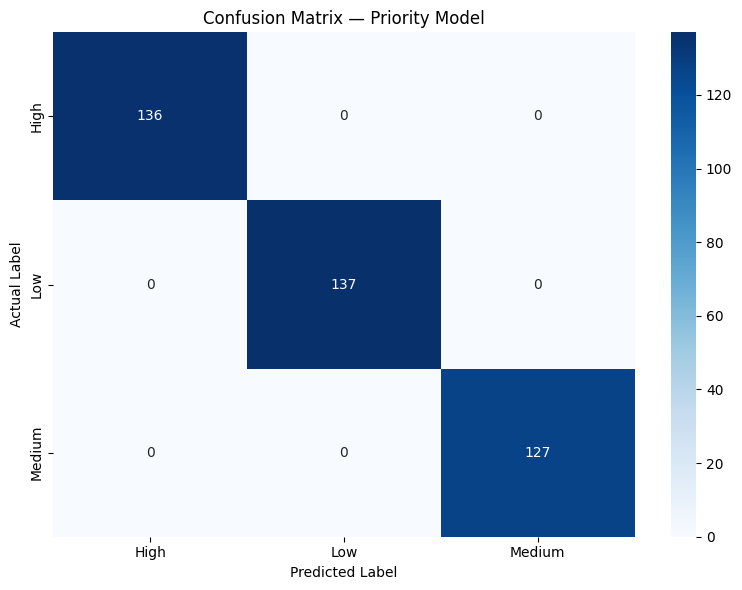


HOW TO READ YOUR RESULTS:
------------------------------------------------------------
Precision : of all complaints predicted as X, how many truly were X
Recall    : of all true X complaints, how many did the model catch
F1-score  : balance between precision and recall (main metric)
Support   : how many real samples of that label in validation set

Diagonal of confusion matrix = correct predictions (want HIGH)
Off-diagonal = mistakes (want LOW or ZERO)

Target for final year project: F1-score above 0.80 for all labels


In [ ]:
# ── Full Evaluation Cell ───────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert numbers back to label names
pred_names  = le.inverse_transform(all_preds)
label_names = le.inverse_transform(all_labels)

# ── 1. Classification Report ──────────────────────────────────────────────────
print("=" * 60)
print("  CLASSIFICATION REPORT — PRIORITY MODEL")
print("=" * 60)
print(classification_report(label_names, pred_names))

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(label_names, pred_names, labels=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Priority Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ── 3. Plain English Summary ──────────────────────────────────────────────────
print("\nHOW TO READ YOUR RESULTS:")
print("-" * 60)
print("Precision : of all complaints predicted as X, how many truly were X")
print("Recall    : of all true X complaints, how many did the model catch")
print("F1-score  : balance between precision and recall (main metric)")
print("Support   : how many real samples of that label in validation set")
print("\nDiagonal of confusion matrix = correct predictions (want HIGH)")
print("Off-diagonal = mistakes (want LOW or ZERO)")
print("\nTarget for final year project: F1-score above 0.80 for all labels")

result boht acha aa raha tha is liye we checked k ye theek hai ya overfitted. ab hum unseen sentences use karain gae to test whether it is actually good ya nahi

In [ ]:
# ── Diagnosis Cell ─────────────────────────────────────────────────────────────

# Check 1: are any validation texts identical or near-identical to training texts?
train_set = set(X_train)
val_set   = set(X_val)

exact_overlap = train_set.intersection(val_set)
print(f"Exact overlapping texts between train and val: {len(exact_overlap)}")

# Check 2: test with completely new sentences the model has NEVER seen
# These are not from your dataset at all
print("\n── Testing on brand new unseen sentences ──")

fresh_tests = [
    # These sound like your data but were never in it
    ("wifi in the hostel is not working since yesterday",           "Medium"),
    ("teacher gave me zero without checking my paper",              "High"),
    ("canteen should add more food options",                        "Low"),
    ("my account was hacked and i cant login",                      "High"),
    ("bus was late again today by 30 minutes",                      "Medium"),
    ("library needs more seating during exams",                     "Low"),
    ("found a dead insect in my food",                              "High"),
    ("lecture slides are hard to read",                             "Low"),
    ("scholarship hasnt been paid for 6 weeks",                     "Medium"),
    ("a classmate has been threatening me every day",               "High"),
]

model.eval()
passed = 0
print(f"\n{'COMPLAINT':<50} {'EXPECTED':<10} {'PREDICTED':<10} {'CONF':<8} {'OK?'}")
print("=" * 90)

for text, expected in fresh_tests:
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=128,
        padding='max_length'
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()

    predicted  = le.inverse_transform([pred_id])[0]
    confidence = probs[0][pred_id].item() * 100
    ok         = "✓" if predicted == expected else "✗"
    if predicted == expected:
        passed += 1

    print(f"{text:<50} {expected:<10} {predicted:<10} {confidence:<8.1f} {ok}")

print(f"\nResult: {passed}/{len(fresh_tests)} correct on brand new sentences")
print("\nIf this score is also 10/10 → likely overfitting to templates")
print("If this score is 7-9/10   → model is genuinely good")
print("If this score is below 6  → model memorized, needs real data")

Exact overlapping texts between train and val: 0

── Testing on brand new unseen sentences ──

COMPLAINT                                          EXPECTED   PREDICTED  CONF     OK?
wifi in the hostel is not working since yesterday  Medium     Medium     66.3     ✓
teacher gave me zero without checking my paper     High       Medium     88.5     ✗
canteen should add more food options               Low        Low        99.7     ✓
my account was hacked and i cant login             High       High       99.4     ✓
bus was late again today by 30 minutes             Medium     Medium     99.3     ✓
library needs more seating during exams            Low        Low        98.7     ✓
found a dead insect in my food                     High       High       99.3     ✓
lecture slides are hard to read                    Low        Low        99.5     ✓
scholarship hasnt been paid for 6 weeks            Medium     Medium     99.5     ✓
a classmate has been threatening me every day      High       H